In [1]:
"""
Fragment 1 — Data Loading
==========================
Custom CNN 9L Binary Hybrid Pipeline — Feature Extraction + ML Classification

- Loads train, val and test data from disk
- Augmented folder already exists — no new augmentation
- Uses simple rescale 1/255 — custom CNN has no pretrained
  preprocessing requirements
- All three sets loaded here since feature extraction
  requires passing images through the trained CNN once
- shuffle=False on all sets — required for correct label
  alignment during feature extraction
- Features will be extracted in Fragments 3 and 4 per run
- Binary classification — Mold vs No Mold
"""

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Safety Guards ─────────────────────────────────────────────────────────────

assert os.path.exists(AUG_DIR), \
    f"Augmented folder not found: {AUG_DIR}"
assert os.path.exists(VALID_DIR), \
    f"Validation folder not found: {VALID_DIR}"
assert os.path.exists(TEST_DIR), \
    f"Test folder not found: {TEST_DIR}"

# ── Step 1: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str, test_dir: str):
    """
    Builds generators for all three sets.
    Custom CNN has no pretrained preprocessing so simple
    rescale to [0, 1] is applied — consistent across all
    three sets and matching the DL training pipeline.
    shuffle=False on all sets — critical for correct label
    alignment when extracting features batch by batch.
    class_mode = 'binary' — Mold vs No Mold.
    """

    train_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,    # must be False for feature extraction
    )

    valid_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    test_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    return train_generator, valid_generator, test_generator

# ── Step 2: Run and Summarise ─────────────────────────────────────────────────

train_generator, valid_generator, test_generator = build_generators(
    AUG_DIR, VALID_DIR, TEST_DIR
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Fragment 1 — Data Generators Ready")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Model         : Custom CNN 9L + SVM / KNN (Hybrid)")
print(f"  Train source  : augmented/   (shared, no new aug)")
print(f"  Valid source  : val/")
print(f"  Test source   : test/")
print(f"  Preprocessing : rescale 1/255")
print(f"  Shuffle       : False on all sets (required for")
print(f"                  correct label alignment)")
print(f"  Train samples : {train_generator.samples}")
print(f"  Valid samples : {valid_generator.samples}")
print(f"  Test samples  : {test_generator.samples}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Class indices : {train_generator.class_indices}")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     train_generator, valid_generator and test_generator are ready.")
print("     Proceed to Fragment 2 — Checkpoint Validation.\n")


Found 58813 images belonging to 2 classes.
Found 648 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  Fragment 1 — Data Generators Ready
  Pipeline      : Binary — Mold vs No Mold
  Model         : Custom CNN 9L + SVM / KNN (Hybrid)
  Train source  : augmented/   (shared, no new aug)
  Valid source  : val/
  Test source   : test/
  Preprocessing : rescale 1/255
  Shuffle       : False on all sets (required for
                  correct label alignment)
  Train samples : 58813
  Valid samples : 648
  Test samples  : 649
  Classes       : ['Mold', 'No mold']
  Class indices : {'Mold': 0, 'No mold': 1}
  Image size    : (224, 224)
  Batch size    : 32

  ✓ Fragment 1 complete.
     train_generator, valid_generator and test_generator are ready.
     Proceed to Fragment 2 — Checkpoint Validation.



In [2]:
"""
Fragment 2 — Checkpoint Validation
====================================
Custom CNN 9L Binary Hybrid Pipeline

Verifies all 5 CNN 9L binary checkpoints exist before
Fragment 3 (SVM) and Fragment 4 (KNN) attempt to load them.
Reports val_auc from each run's CSV log for reference.
No feature extraction here — each classifier fragment
loads its own checkpoint per run.

Design: run N → custom_cnn9_binary_runN_best.keras
"""

import os
import pandas as pd

SAVE_DIR   = r"D:\Mold Studies Binary\Models"
TOTAL_RUNS = 5

print("=" * 60)
print("  Fragment 2 — Checkpoint Validation")
print("=" * 60)
print(f"  Pipeline : Binary — Mold vs No Mold")
print(f"  Design   : run N → custom_cnn9_binary_runN_best.keras")
print("=" * 60)

all_checkpoints_valid = True

for run_idx in range(1, TOTAL_RUNS + 1):

    ckpt_name = f"custom_cnn9_binary_run{run_idx}_best.keras"
    ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

    if run_idx == 1:
        csv_path = os.path.join(SAVE_DIR,
                                "custom_cnn9_binary_training_log.csv")
    else:
        csv_path = os.path.join(SAVE_DIR,
                                f"custom_cnn9_binary_run{run_idx}_log.csv")

    ckpt_ok = os.path.exists(ckpt_path)
    csv_ok  = os.path.exists(csv_path)

    val_auc = float("nan")
    if csv_ok:
        log     = pd.read_csv(csv_path)
        val_auc = max(log["val_auc"])

    status = "✓" if ckpt_ok else "✗ MISSING"
    print(f"  Run {run_idx}  {status:<10}  val_auc={val_auc:.4f}  {ckpt_name}")

    if not ckpt_ok:
        all_checkpoints_valid = False

print("=" * 60)

if all_checkpoints_valid:
    print("\n  ✓ All 5 checkpoints found.")
    print("     Proceed to Fragment 3 — SVM Classification.\n")
else:
    print("\n  ✗ One or more checkpoints missing.")
    print("     Ensure CNN 9L Binary Fragment 3b completed")
    print("     successfully before continuing.\n")

  Fragment 2 — Checkpoint Validation
  Pipeline : Binary — Mold vs No Mold
  Design   : run N → custom_cnn9_binary_runN_best.keras
  Run 1  ✓           val_auc=0.9942  custom_cnn9_binary_run1_best.keras
  Run 2  ✓           val_auc=0.9927  custom_cnn9_binary_run2_best.keras
  Run 3  ✓           val_auc=0.9936  custom_cnn9_binary_run3_best.keras
  Run 4  ✓           val_auc=0.9966  custom_cnn9_binary_run4_best.keras
  Run 5  ✓           val_auc=0.9921  custom_cnn9_binary_run5_best.keras

  ✓ All 5 checkpoints found.
     Proceed to Fragment 3 — SVM Classification.



  Fragment 3 — Custom CNN 9L Binary + SVM  (5 Runs)
  Pipeline       : Binary — Mold vs No Mold
  Design         : each run uses its own CNN binary checkpoint
  Feature source : Dense(128) from custom_cnn9_binary_run{N}_best.keras
  Kernel         : linear
  C              : 1.0
  Threshold      : 0.5
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  CNN 9L Binary + SVM
  CNN checkpoint : custom_cnn9_binary_run1_best.keras
  SVM seed       : 27

  Loading checkpoint : custom_cnn9_binary_run1_best.keras


Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9942
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training SVM on CNN 9L binary run 1 features...
  ✓ Training complete

  Run 1 Results
    CNN val_auc  : 0.9942
    SVM Accuracy : 0.9630
    Precision    : 0.9508
    Sensitivity  : 0.9866
    Specificity  : 0.9314
    F1 Score     : 0.9683
    AUC          : 0.9911
    TP=367  TN=258  FP=19

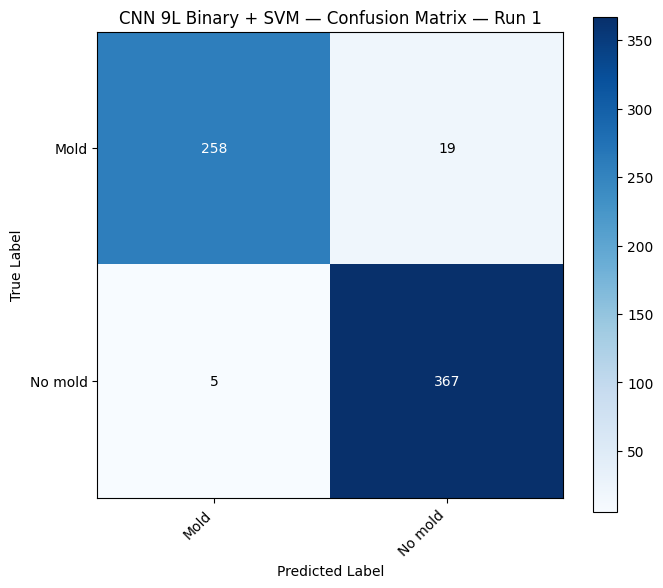

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_confusion_matrix_run1.png


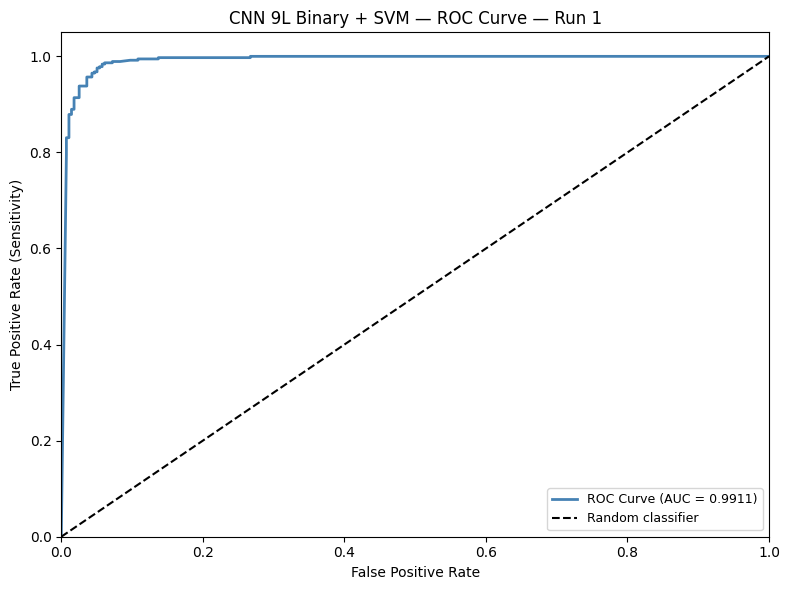

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_roc_curve_run1.png


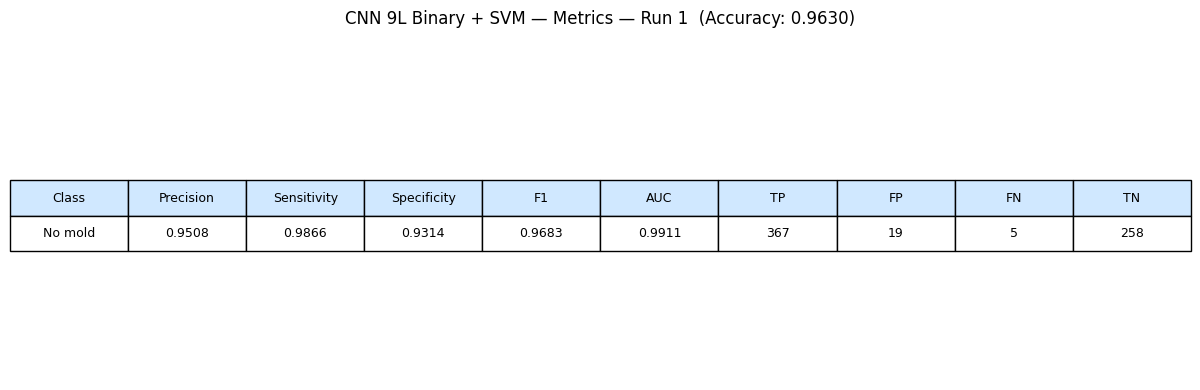

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_metrics_table_run1.png

  RUN 2 / 5  —  CNN 9L Binary + SVM
  CNN checkpoint : custom_cnn9_binary_run2_best.keras
  SVM seed       : 42

  Loading checkpoint : custom_cnn9_binary_run2_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9927
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training SVM on CNN 9L binary run 2 features...
  ✓ Training complete

  Run 2 Results
    CNN val_auc  : 0.9927
    SVM Accuracy : 0.9676
    Precision    : 0.9655
    Sensitivity  : 0.9785
    Specificity  : 0.9531
    F1 Score     : 0.9720
    AUC          : 0.9895
    TP=364  TN=264  FP=13  FN=8


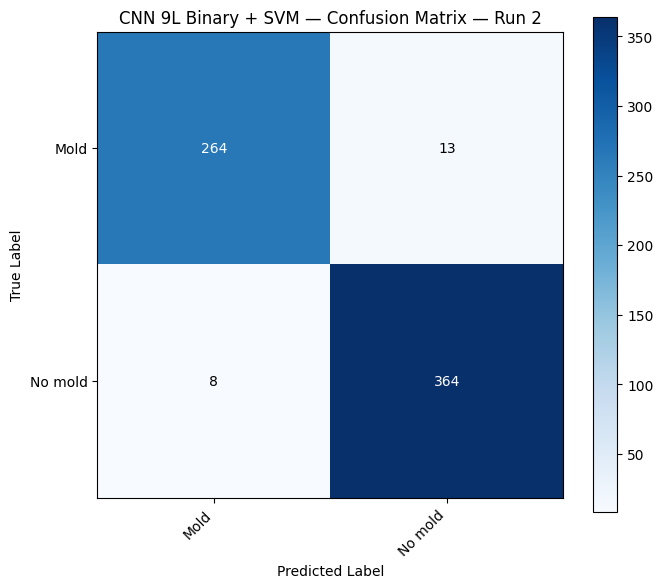

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_confusion_matrix_run2.png


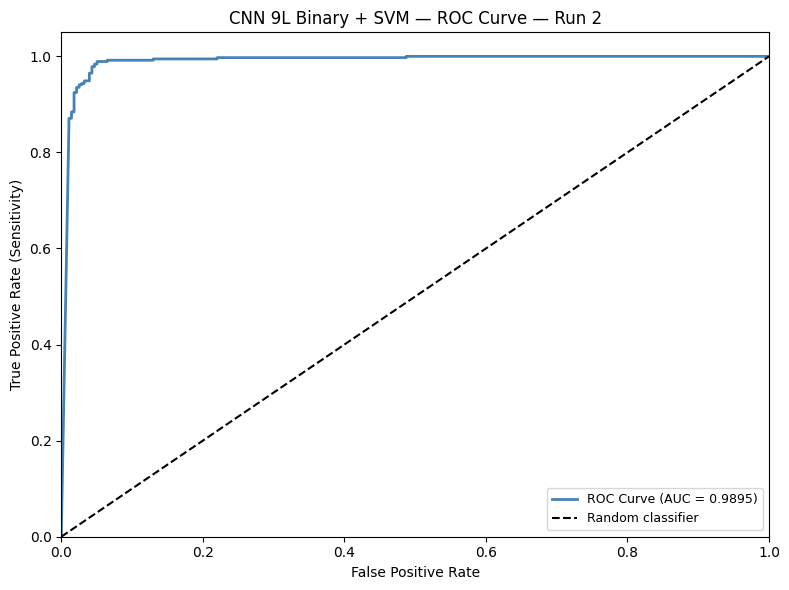

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_roc_curve_run2.png


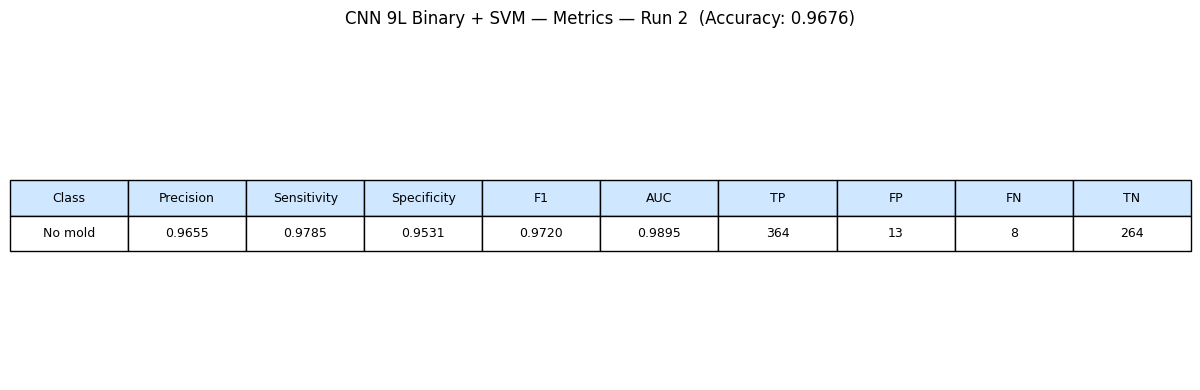

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_metrics_table_run2.png

  RUN 3 / 5  —  CNN 9L Binary + SVM
  CNN checkpoint : custom_cnn9_binary_run3_best.keras
  SVM seed       : 99

  Loading checkpoint : custom_cnn9_binary_run3_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9936
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training SVM on CNN 9L binary run 3 features...
  ✓ Training complete

  Run 3 Results
    CNN val_auc  : 0.9936
    SVM Accuracy : 0.9692
    Precision    : 0.9681
    Sensitivity  : 0.9785
    Specificity  : 0.9567
    F1 Score     : 0.9733
    AUC          : 0.9938
    TP=364  TN=265  FP=12  FN=8


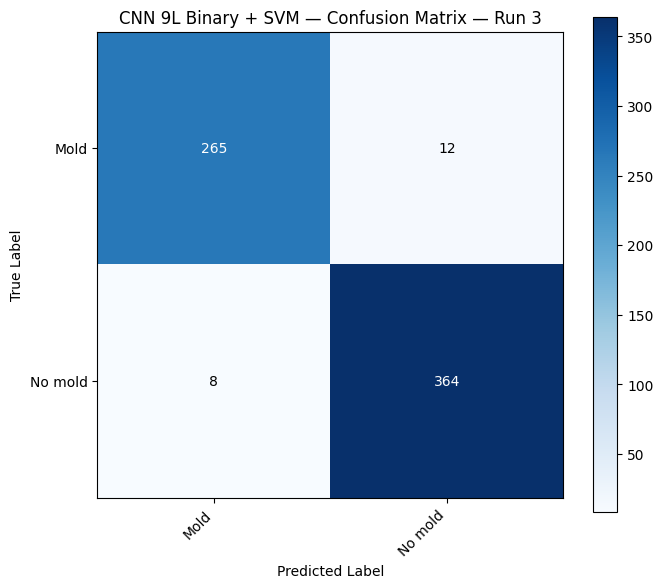

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_confusion_matrix_run3.png


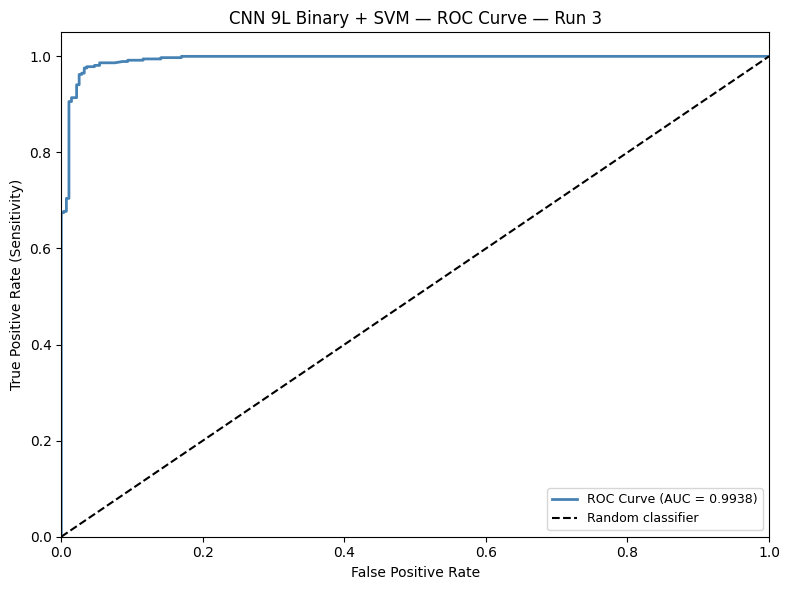

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_roc_curve_run3.png


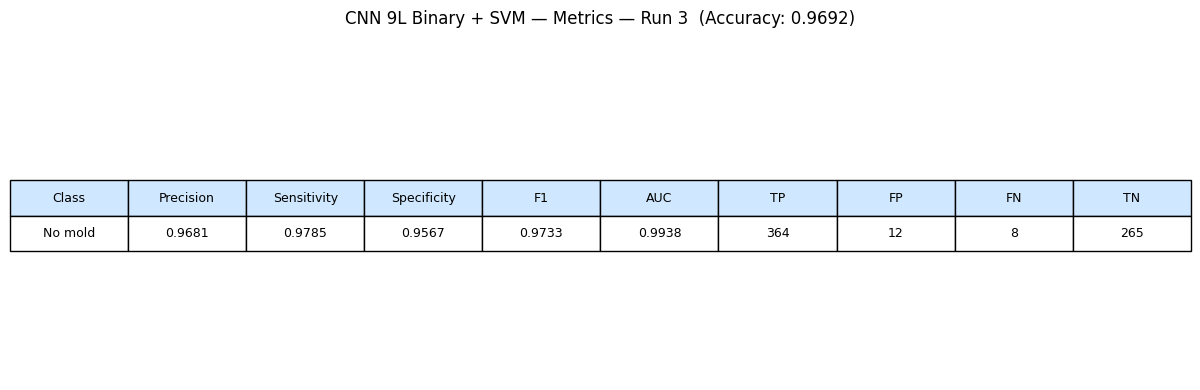

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_metrics_table_run3.png

  RUN 4 / 5  —  CNN 9L Binary + SVM
  CNN checkpoint : custom_cnn9_binary_run4_best.keras
  SVM seed       : 123

  Loading checkpoint : custom_cnn9_binary_run4_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9966
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training SVM on CNN 9L binary run 4 features...
  ✓ Training complete

  Run 4 Results
    CNN val_auc  : 0.9966
    SVM Accuracy : 0.9738
    Precision    : 0.9659
    Sensitivity  : 0.9892
    Specificity  : 0.9531
    F1 Score     : 0.9774
    AUC          : 0.9969
    TP=368  TN=264  FP=13  FN=4


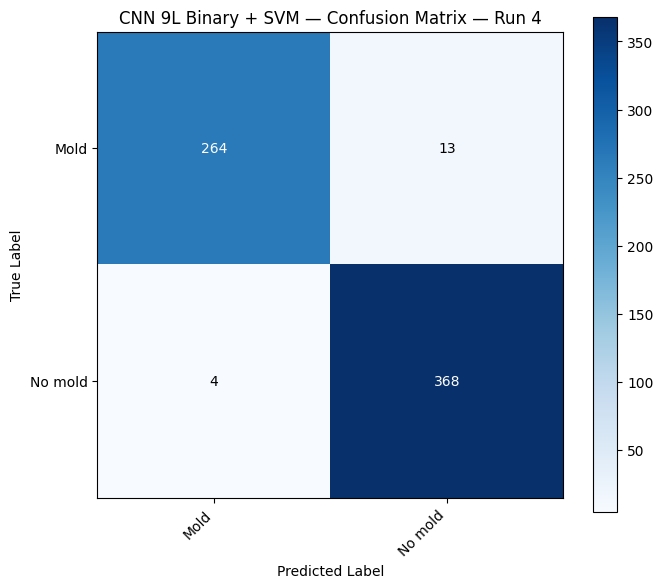

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_confusion_matrix_run4.png


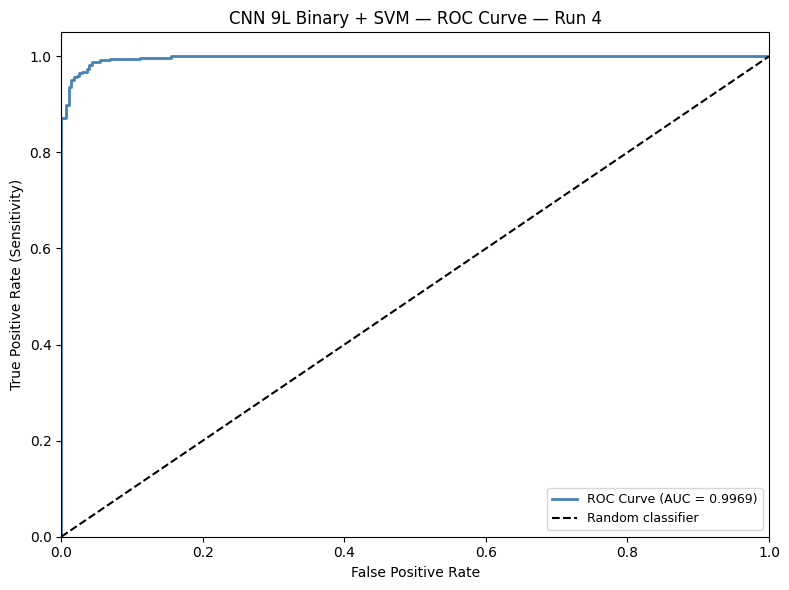

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_roc_curve_run4.png


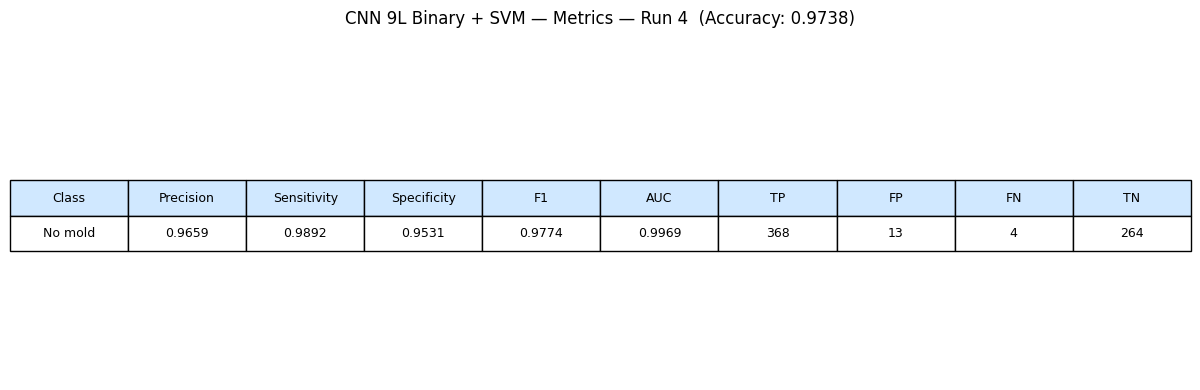

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_metrics_table_run4.png

  RUN 5 / 5  —  CNN 9L Binary + SVM
  CNN checkpoint : custom_cnn9_binary_run5_best.keras
  SVM seed       : 256

  Loading checkpoint : custom_cnn9_binary_run5_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9921
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training SVM on CNN 9L binary run 5 features...
  ✓ Training complete

  Run 5 Results
    CNN val_auc  : 0.9921
    SVM Accuracy : 0.9630
    Precision    : 0.9485
    Sensitivity  : 0.9892
    Specificity  : 0.9278
    F1 Score     : 0.9684
    AUC          : 0.9851
    TP=368  TN=257  FP=20  FN=4


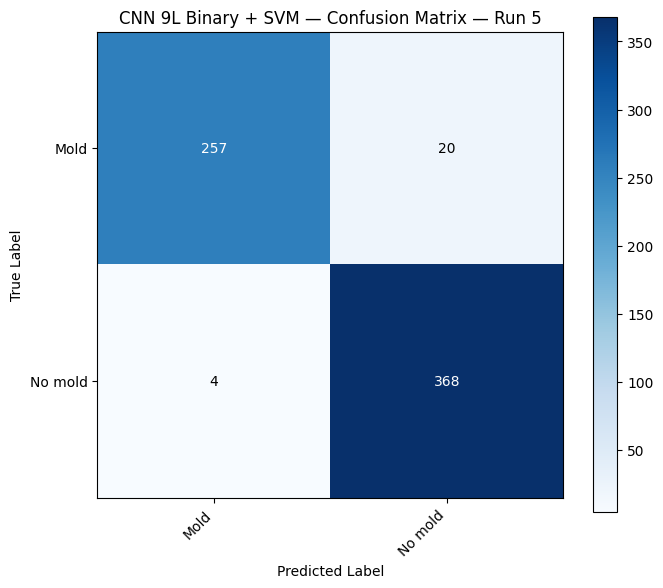

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_confusion_matrix_run5.png


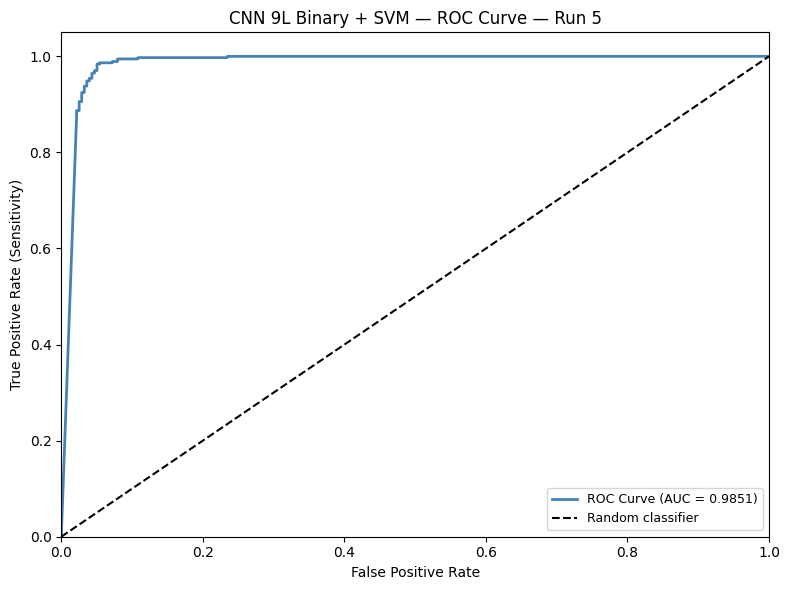

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_roc_curve_run5.png


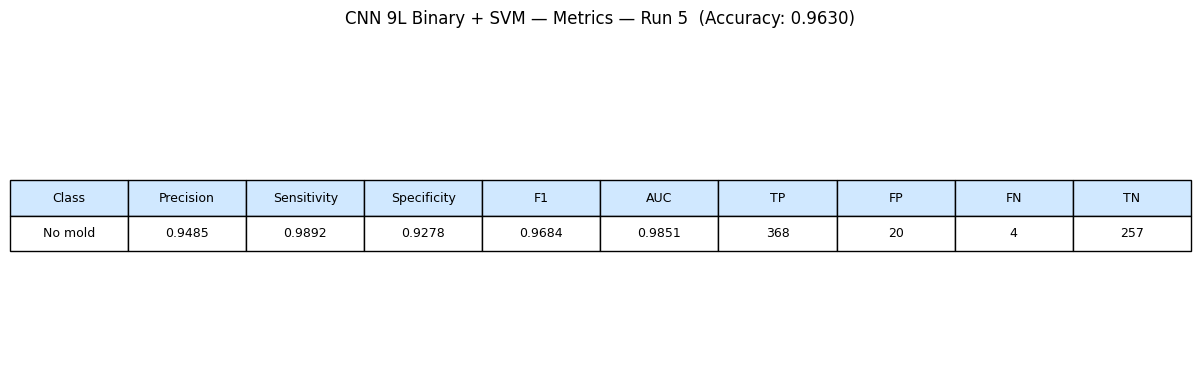

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_svm\cnn9_binary_svm_metrics_table_run5.png

  PER-RUN RESULTS — Custom CNN 9L Binary + SVM
  Run     CNN ValAUC    Test Acc   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────────────────
  1           0.9942      0.9630      0.9508        0.9866        0.9314    0.9683    0.9911
  2           0.9927      0.9676      0.9655        0.9785        0.9531    0.9720    0.9895
  3           0.9936      0.9692      0.9681        0.9785        0.9567    0.9733    0.9938
  4           0.9966      0.9738      0.9659        0.9892        0.9531    0.9774    0.9969
  5           0.9921      0.9630      0.9485        0.9892        0.9278    0.9684    0.9851
──────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────  Statistical Summary  ────────────────────────────
  Metric

In [3]:
"""
Fragment 3 — SVM Classification on Custom CNN 9L Binary Features (5 Runs)
==========================================================================
Custom CNN 9L Binary Hybrid Pipeline — Feature Extraction + SVM

- Each run loads its own CNN 9L binary checkpoint for feature extraction
- Run 1 uses CNN binary run1, Run 2 uses CNN binary run2 etc.
- This reflects genuine variance from 5 independent CNN trainings
- Evaluates on test features — never seen during training
- Computes full binary metrics + 95% confidence intervals
"""

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
TEST_DIR   = os.path.join(DATA_DIR, "test")
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "custom_cnn9_binary_svm")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs(PLOT_DIR, exist_ok=True)

# ── SVM Parameters ────────────────────────────────────────────────────────────

SVM_KERNEL = "linear"
SVM_C      = 1.0
SVM_GAMMA  = "scale"
THRESHOLD  = 0.5

# ── Step 1: Helper — extract features from a specific CNN 9L binary checkpoint

def extract_run_features(run_idx):
    """
    Loads CNN 9L binary checkpoint for run_idx, extracts features
    from train and test sets using Dense(128).
    Each run gets its own feature set reflecting that run's
    learned binary representations.
    Clears session after extraction to free GPU memory.
    """

    ckpt_name = f"custom_cnn9_binary_run{run_idx}_best.keras"
    ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

    print(f"  Loading checkpoint : {ckpt_name}")
    full_model = tf.keras.models.load_model(ckpt_path)

    extractor = Model(
        inputs  = full_model.input,
        outputs = full_model.get_layer("dense_128").output,
        name    = f"cnn9_binary_extractor_run{run_idx}"
    )
    extractor.trainable = False

    train_datagen = ImageDataGenerator(rescale=1.0 / 255)
    train_gen     = train_datagen.flow_from_directory(
        AUG_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    test_datagen  = ImageDataGenerator(rescale=1.0 / 255)
    test_gen      = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    train_gen.reset()
    X_tr = extractor.predict(
        train_gen,
        steps   = np.ceil(train_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_tr = train_gen.classes

    test_gen.reset()
    X_te = extractor.predict(
        test_gen,
        steps   = np.ceil(test_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_te = test_gen.classes

    # Read val_auc from CSV log for reporting
    if run_idx == 1:
        csv_path = os.path.join(SAVE_DIR,
                                "custom_cnn9_binary_training_log.csv")
    else:
        csv_path = os.path.join(SAVE_DIR,
                                f"custom_cnn9_binary_run{run_idx}_log.csv")

    val_auc = float("nan")
    if os.path.exists(csv_path):
        log     = pd.read_csv(csv_path)
        val_auc = max(log["val_auc"])

    class_names = list(train_gen.class_indices.keys())

    print(f"  CNN val_auc        : {val_auc:.4f}")
    print(f"  X_train shape      : {X_tr.shape}")
    print(f"  X_test  shape      : {X_te.shape}")

    del full_model, extractor
    tf.keras.backend.clear_session()
    gc.collect()

    return X_tr, y_tr, X_te, y_te, val_auc, class_names

# ── Step 2: Helper — compute binary metrics ───────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, class_names, save_dir):
    n = len(class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(n),
        yticks      = np.arange(n),
        xticklabels = class_names,
        yticklabels = class_names,
        title       = f"CNN 9L Binary + SVM — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(n):
        for j in range(n):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"cnn9_binary_svm_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"CNN 9L Binary + SVM — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"cnn9_binary_svm_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, class_names, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [[
        class_names[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]
    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]
    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"CNN 9L Binary + SVM — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"cnn9_binary_svm_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 3: 5-Run Loop ────────────────────────────────────────────────────────

print("=" * 60)
print("  Fragment 3 — Custom CNN 9L Binary + SVM  (5 Runs)")
print("=" * 60)
print(f"  Pipeline       : Binary — Mold vs No Mold")
print(f"  Design         : each run uses its own CNN binary checkpoint")
print(f"  Feature source : Dense(128) from custom_cnn9_binary_run{{N}}_best.keras")
print(f"  Kernel         : {SVM_KERNEL}")
print(f"  C              : {SVM_C}")
print(f"  Threshold      : {THRESHOLD}")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  CNN 9L Binary + SVM")
    print(f"  CNN checkpoint : custom_cnn9_binary_run{run_idx}_best.keras")
    print(f"  SVM seed       : {seed}")
    print(f"{'='*60}\n")

    X_tr, y_tr, X_te, y_te, cnn_val_auc, class_names = \
        extract_run_features(run_idx)

    # ── Shuffle train features with this run's seed ───────────────────────────
    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_tr))
    X_tr    = X_tr[indices]
    y_tr    = y_tr[indices]

    # ── Scale features ────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # ── Train SVM ─────────────────────────────────────────────────────────────
    print(f"\n  Training SVM on CNN 9L binary run {run_idx} features...")
    svm = SVC(
        kernel       = SVM_KERNEL,
        C            = SVM_C,
        gamma        = SVM_GAMMA,
        probability  = True,
        random_state = seed,
    )
    svm.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate ──────────────────────────────────────────────────────────────
    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)[:, 1]   # positive class probability

    metrics         = compute_metrics_binary(y_te, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "cnn_val_auc": cnn_val_auc,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "auc"        : metrics["auc"],
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    CNN val_auc  : {cnn_val_auc:.4f}")
    print(f"    SVM Accuracy : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, class_names, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, class_names, PLOT_DIR)

    # ── Memory cleanup ────────────────────────────────────────────────────────
    del X_tr, X_te, X_tr_sc, X_te_sc, svm, scaler
    gc.collect()

# ── Step 4: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_cnn  = 12
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_cnn + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_cnn + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — Custom CNN 9L Binary + SVM")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'CNN ValAUC':>{col_cnn}}"
    f"{'Test Acc':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['cnn_val_auc']:>{col_cnn}.4f}"
        f"{r['accuracy']:>{col_acc}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['specificity']:>{col_spec}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 5: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*28}  Statistical Summary  {'─'*28}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "CNN Val AUC": [r["cnn_val_auc"] for r in all_run_results],
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["auc"]         for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 6: Best Run ──────────────────────────────────────────────────────────

best_run = max(all_run_results, key=lambda x: x["auc"])

print(f"\n  Best run     : Run {best_run['run']} (by AUC)  "
      f"CNN val_auc={best_run['cnn_val_auc']:.4f}")
print(f"  Accuracy     : {best_run['accuracy']:.4f}")
print(f"  Sensitivity  : {best_run['recall']:.4f}")
print(f"  Specificity  : {best_run['specificity']:.4f}")
print(f"  F1 Score     : {best_run['f1']:.4f}")
print(f"  AUC          : {best_run['auc']:.4f}")

# ── Step 7: Expose for comparison ─────────────────────────────────────────────

custom_cnn9_binary_svm_all_metrics     = all_metrics
custom_cnn9_binary_svm_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 3 complete.")
print(f"     custom_cnn9_binary_svm_all_metrics and")
print(f"     custom_cnn9_binary_svm_all_run_results ready.")
print(f"     Proceed to Fragment 4 — KNN on CNN 9L Binary features.\n")

  Fragment 4 — Custom CNN 9L Binary + KNN  (5 Runs)
  Pipeline       : Binary — Mold vs No Mold
  Design         : each run uses its own CNN binary checkpoint
  Feature source : Dense(128) from custom_cnn9_binary_run{N}_best.keras
  N Neighbours   : 5
  Metric         : euclidean
  Weights        : distance
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  CNN 9L Binary + KNN
  CNN checkpoint : custom_cnn9_binary_run1_best.keras
  KNN seed       : 27

  Loading checkpoint : custom_cnn9_binary_run1_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9942
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training KNN on CNN 9L binary run 1 features...
  ✓ Training complete
  Predicting...

  Run 1 Results
    CNN val_auc  : 0.9942
    KNN Accuracy : 0.9569
    Precision    : 0.9388
    Sensitivity  : 0.9892
    Specificity  : 0.9134
    F1 Score     : 0.9634
    AUC          : 0.9703
    T

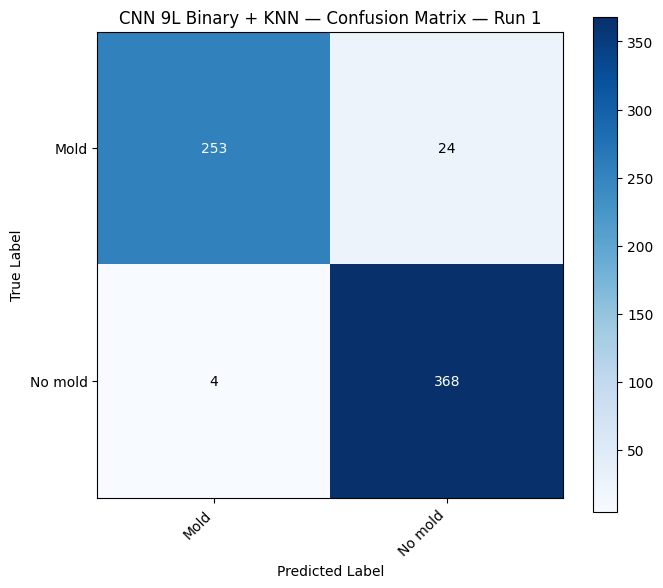

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_confusion_matrix_run1.png


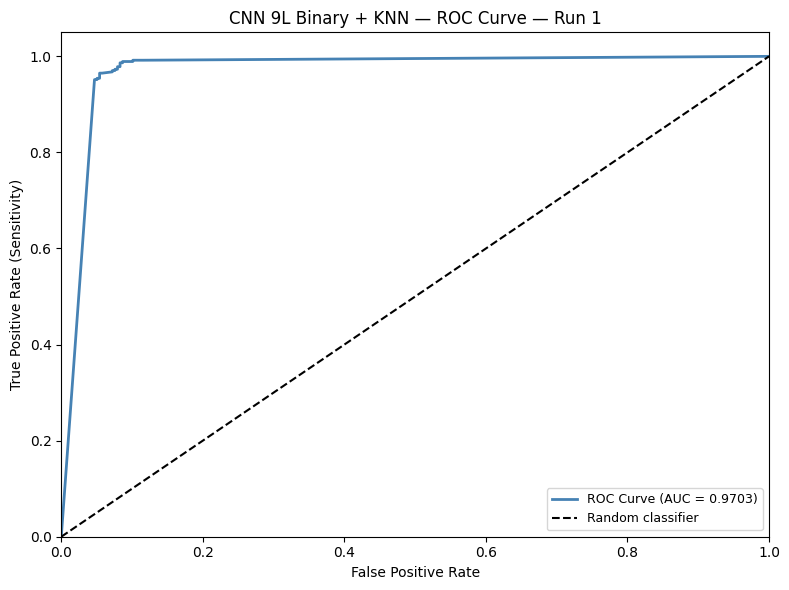

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_roc_curve_run1.png


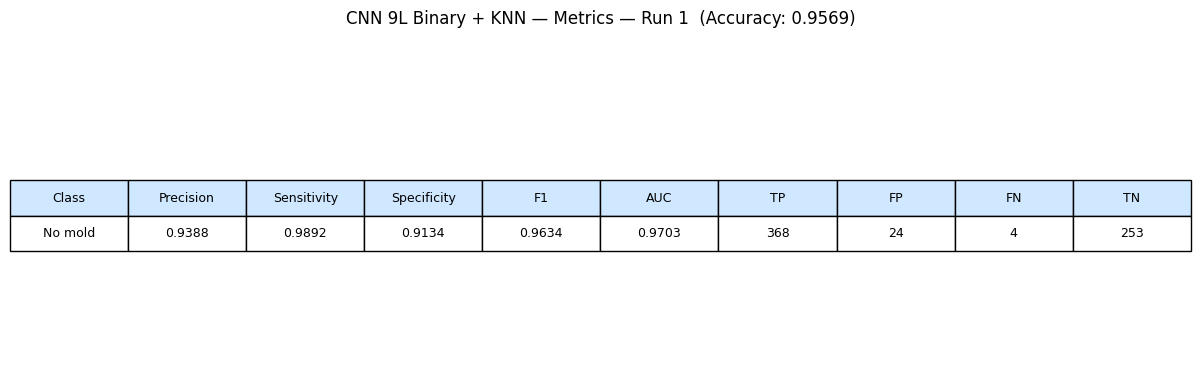

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_metrics_table_run1.png

  RUN 2 / 5  —  CNN 9L Binary + KNN
  CNN checkpoint : custom_cnn9_binary_run2_best.keras
  KNN seed       : 42

  Loading checkpoint : custom_cnn9_binary_run2_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9927
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training KNN on CNN 9L binary run 2 features...
  ✓ Training complete
  Predicting...

  Run 2 Results
    CNN val_auc  : 0.9927
    KNN Accuracy : 0.9692
    Precision    : 0.9656
    Sensitivity  : 0.9812
    Specificity  : 0.9531
    F1 Score     : 0.9733
    AUC          : 0.9812
    TP=365  TN=264  FP=13  FN=7


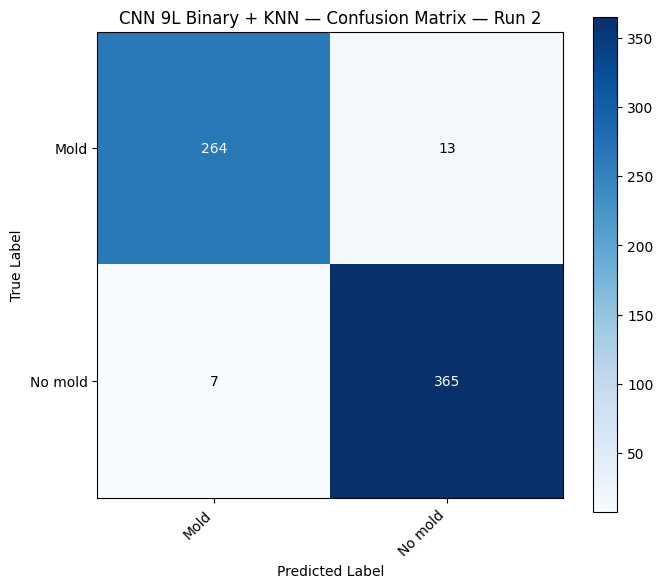

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_confusion_matrix_run2.png


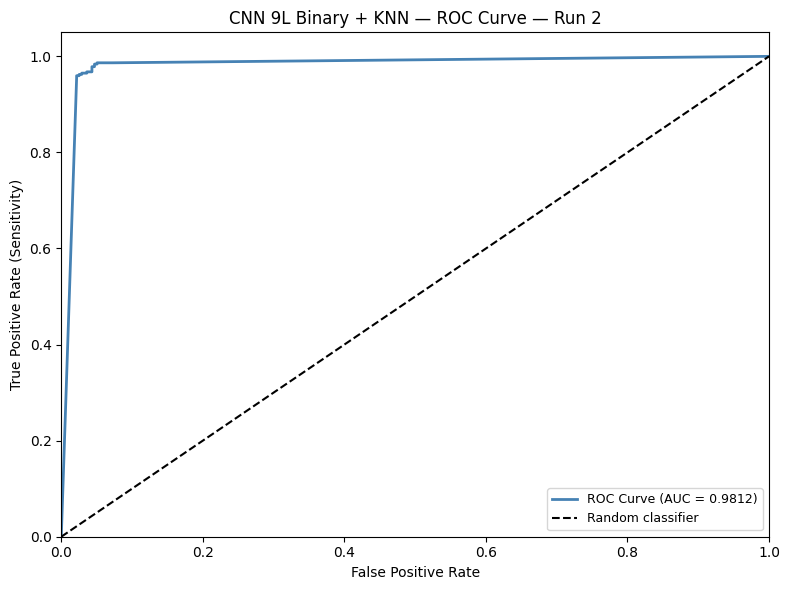

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_roc_curve_run2.png


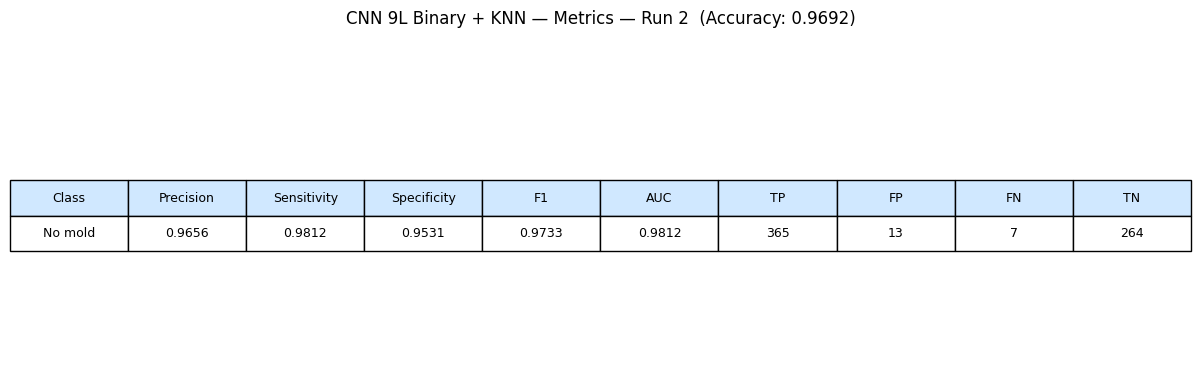

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_metrics_table_run2.png

  RUN 3 / 5  —  CNN 9L Binary + KNN
  CNN checkpoint : custom_cnn9_binary_run3_best.keras
  KNN seed       : 99

  Loading checkpoint : custom_cnn9_binary_run3_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9936
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training KNN on CNN 9L binary run 3 features...
  ✓ Training complete
  Predicting...

  Run 3 Results
    CNN val_auc  : 0.9936
    KNN Accuracy : 0.9692
    Precision    : 0.9681
    Sensitivity  : 0.9785
    Specificity  : 0.9567
    F1 Score     : 0.9733
    AUC          : 0.9795
    TP=364  TN=265  FP=12  FN=8


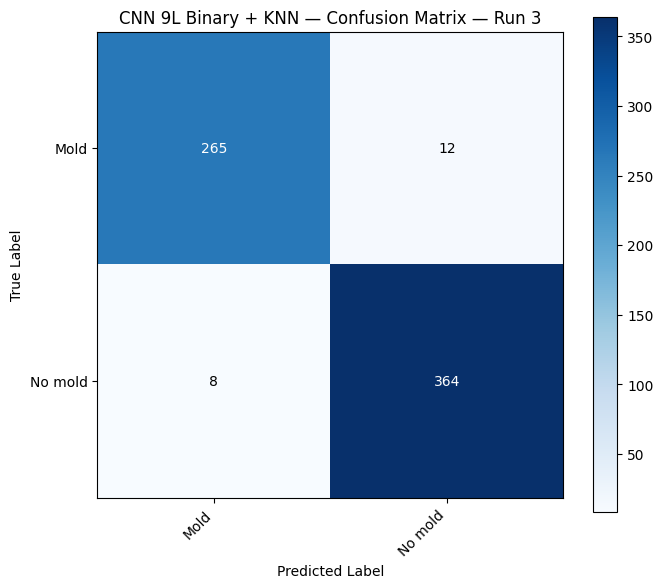

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_confusion_matrix_run3.png


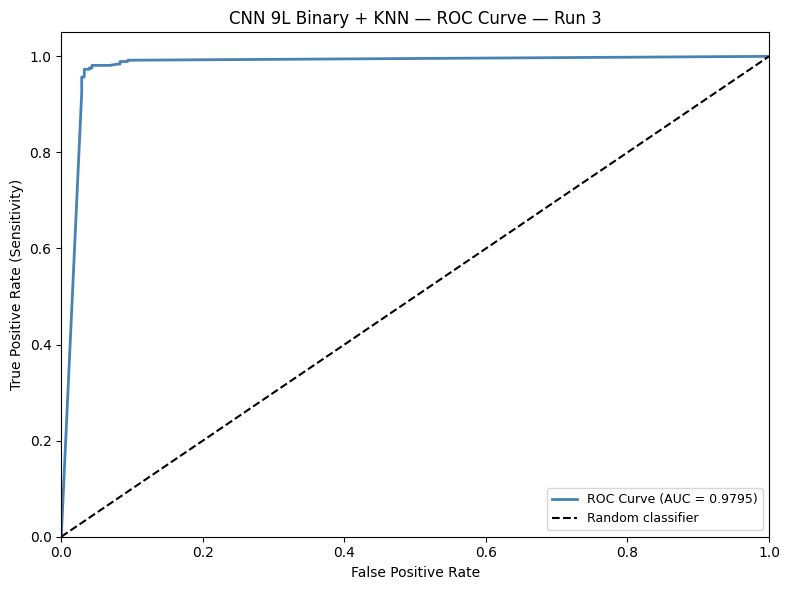

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_roc_curve_run3.png


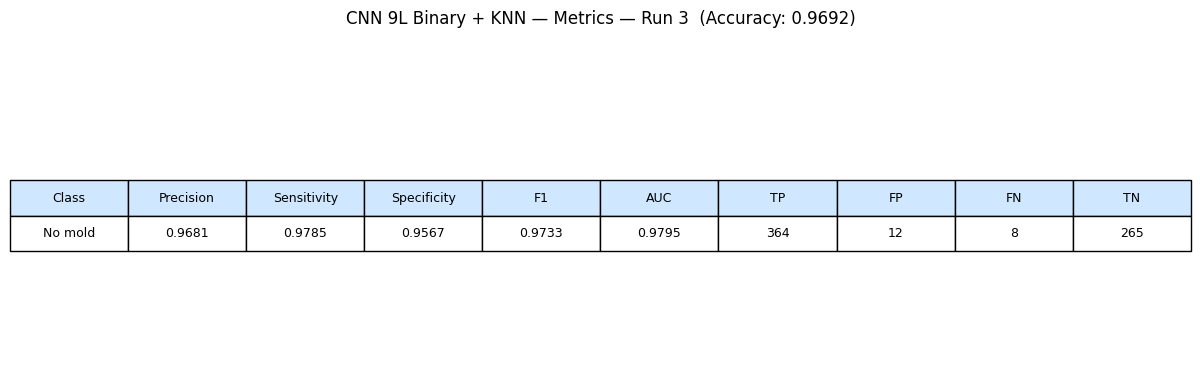

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_metrics_table_run3.png

  RUN 4 / 5  —  CNN 9L Binary + KNN
  CNN checkpoint : custom_cnn9_binary_run4_best.keras
  KNN seed       : 123

  Loading checkpoint : custom_cnn9_binary_run4_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9966
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training KNN on CNN 9L binary run 4 features...
  ✓ Training complete
  Predicting...

  Run 4 Results
    CNN val_auc  : 0.9966
    KNN Accuracy : 0.9723
    Precision    : 0.9683
    Sensitivity  : 0.9839
    Specificity  : 0.9567
    F1 Score     : 0.9760
    AUC          : 0.9822
    TP=366  TN=265  FP=12  FN=6


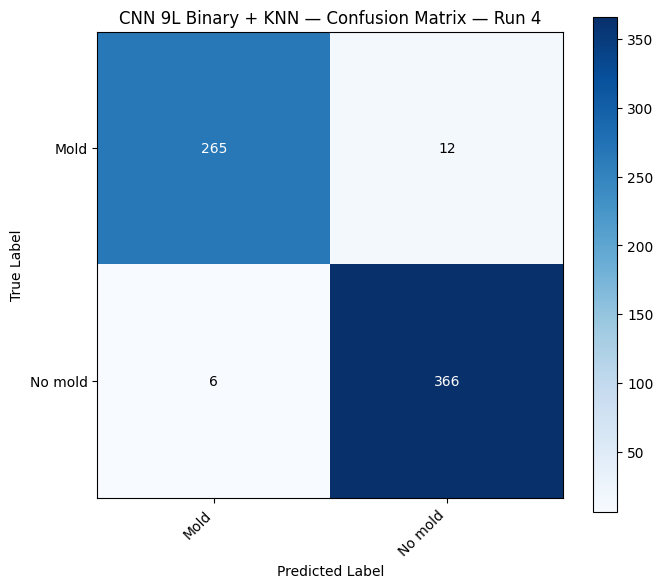

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_confusion_matrix_run4.png


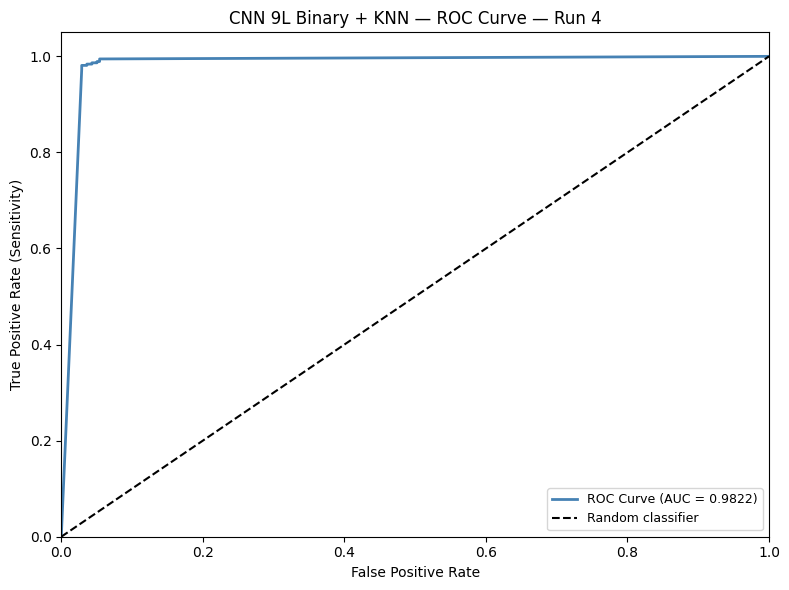

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_roc_curve_run4.png


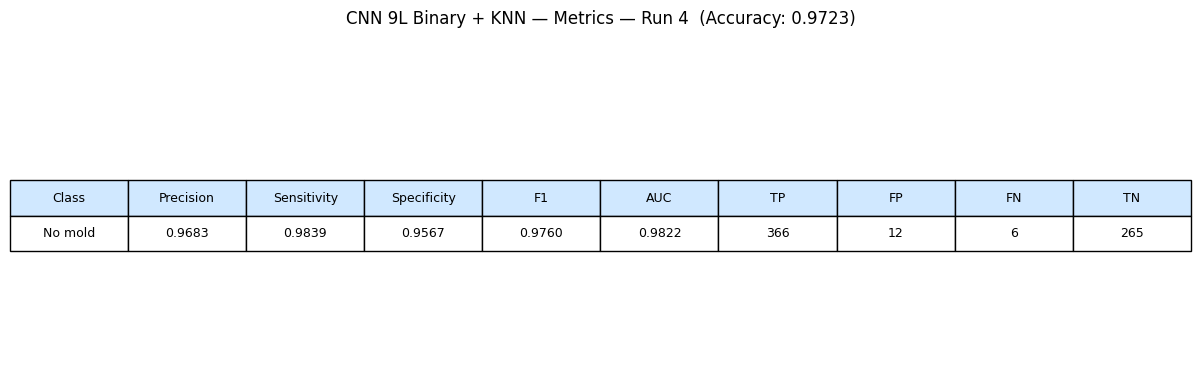

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_metrics_table_run4.png

  RUN 5 / 5  —  CNN 9L Binary + KNN
  CNN checkpoint : custom_cnn9_binary_run5_best.keras
  KNN seed       : 256

  Loading checkpoint : custom_cnn9_binary_run5_best.keras
Found 58813 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  CNN val_auc        : 0.9921
  X_train shape      : (58813, 128)
  X_test  shape      : (649, 128)

  Training KNN on CNN 9L binary run 5 features...
  ✓ Training complete
  Predicting...

  Run 5 Results
    CNN val_auc  : 0.9921
    KNN Accuracy : 0.9646
    Precision    : 0.9509
    Sensitivity  : 0.9892
    Specificity  : 0.9314
    F1 Score     : 0.9697
    AUC          : 0.9716
    TP=368  TN=258  FP=19  FN=4


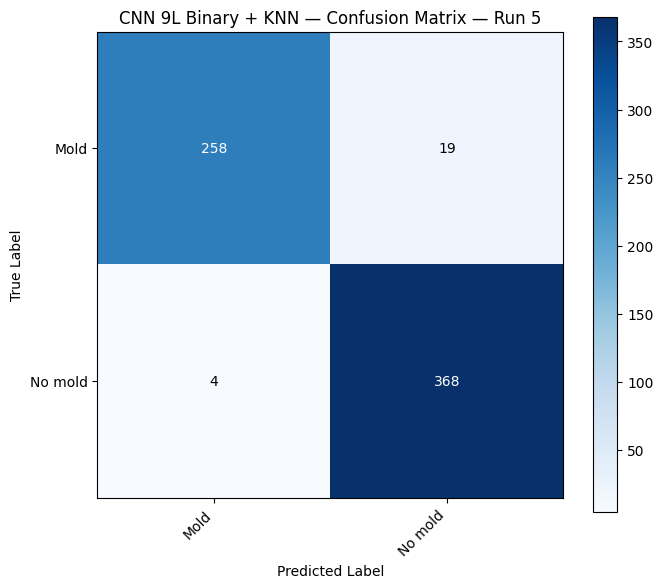

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_confusion_matrix_run5.png


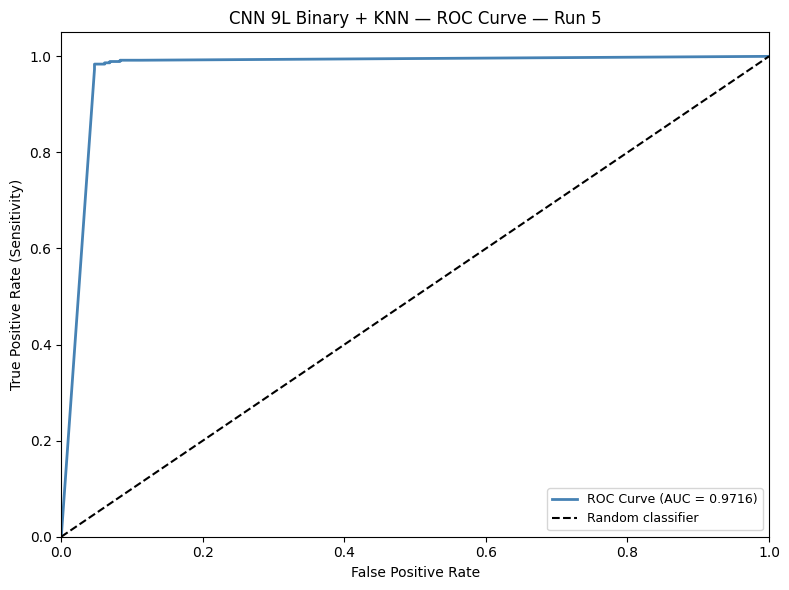

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_roc_curve_run5.png


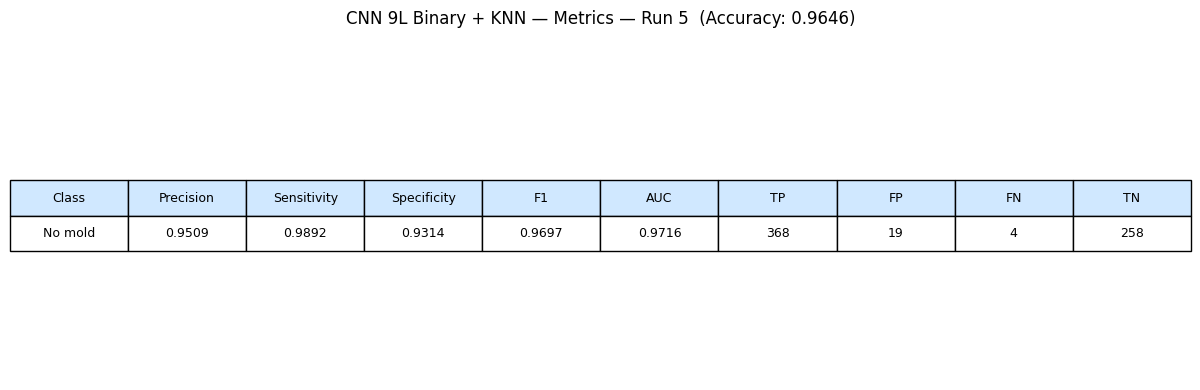

  Saved: D:\Mold Studies Binary\Models\plots\custom_cnn9_binary_knn\cnn9_binary_knn_metrics_table_run5.png

  PER-RUN RESULTS — Custom CNN 9L Binary + KNN
  Run     CNN ValAUC    Test Acc   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────────────────
  1           0.9942      0.9569      0.9388        0.9892        0.9134    0.9634    0.9703
  2           0.9927      0.9692      0.9656        0.9812        0.9531    0.9733    0.9812
  3           0.9936      0.9692      0.9681        0.9785        0.9567    0.9733    0.9795
  4           0.9966      0.9723      0.9683        0.9839        0.9567    0.9760    0.9822
  5           0.9921      0.9646      0.9509        0.9892        0.9314    0.9697    0.9716
──────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────  Statistical Summary  ────────────────────────────
  Metric

In [4]:
"""
Fragment 4 — KNN Classification on Custom CNN 9L Binary Features (5 Runs)
==========================================================================
Custom CNN 9L Binary Hybrid Pipeline — Feature Extraction + KNN

- Each run loads its own CNN 9L binary checkpoint for feature extraction
- Run 1 uses CNN binary run1, Run 2 uses CNN binary run2 etc.
- This reflects genuine variance from 5 independent CNN trainings
- Evaluates on test features — never seen during training
- Computes full binary metrics + 95% confidence intervals
"""

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
TEST_DIR   = os.path.join(DATA_DIR, "test")
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "custom_cnn9_binary_knn")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs(PLOT_DIR, exist_ok=True)

# ── KNN Parameters ────────────────────────────────────────────────────────────

KNN_N_NEIGHBORS = 5
KNN_METRIC      = "euclidean"
KNN_WEIGHTS     = "distance"
THRESHOLD       = 0.5

# ── Step 1: Helper — extract features from a specific CNN 9L binary checkpoint

def extract_run_features(run_idx):
    """
    Loads CNN 9L binary checkpoint for run_idx, extracts features
    from train and test sets using Dense(128).
    Each run gets its own feature set reflecting that run's
    learned binary representations.
    Clears session after extraction to free GPU memory.
    """

    ckpt_name = f"custom_cnn9_binary_run{run_idx}_best.keras"
    ckpt_path = os.path.join(SAVE_DIR, ckpt_name)

    print(f"  Loading checkpoint : {ckpt_name}")
    full_model = tf.keras.models.load_model(ckpt_path)

    extractor = Model(
        inputs  = full_model.input,
        outputs = full_model.get_layer("dense_128").output,
        name    = f"cnn9_binary_extractor_run{run_idx}"
    )
    extractor.trainable = False

    train_datagen = ImageDataGenerator(rescale=1.0 / 255)
    train_gen     = train_datagen.flow_from_directory(
        AUG_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    test_datagen  = ImageDataGenerator(rescale=1.0 / 255)
    test_gen      = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    train_gen.reset()
    X_tr = extractor.predict(
        train_gen,
        steps   = np.ceil(train_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_tr = train_gen.classes

    test_gen.reset()
    X_te = extractor.predict(
        test_gen,
        steps   = np.ceil(test_gen.samples / BATCH_SIZE),
        verbose = 0,
    )
    y_te = test_gen.classes

    if run_idx == 1:
        csv_path = os.path.join(SAVE_DIR,
                                "custom_cnn9_binary_training_log.csv")
    else:
        csv_path = os.path.join(SAVE_DIR,
                                f"custom_cnn9_binary_run{run_idx}_log.csv")

    val_auc = float("nan")
    if os.path.exists(csv_path):
        log     = pd.read_csv(csv_path)
        val_auc = max(log["val_auc"])

    class_names = list(train_gen.class_indices.keys())

    print(f"  CNN val_auc        : {val_auc:.4f}")
    print(f"  X_train shape      : {X_tr.shape}")
    print(f"  X_test  shape      : {X_te.shape}")

    del full_model, extractor
    tf.keras.backend.clear_session()
    gc.collect()

    return X_tr, y_tr, X_te, y_te, val_auc, class_names

# ── Step 2: Helper — compute binary metrics ───────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, class_names, save_dir):
    n = len(class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(n),
        yticks      = np.arange(n),
        xticklabels = class_names,
        yticklabels = class_names,
        title       = f"CNN 9L Binary + KNN — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(n):
        for j in range(n):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"cnn9_binary_knn_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"CNN 9L Binary + KNN — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"cnn9_binary_knn_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, class_names, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [[
        class_names[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]
    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]
    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"CNN 9L Binary + KNN — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"cnn9_binary_knn_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 3: 5-Run Loop ────────────────────────────────────────────────────────

print("=" * 60)
print("  Fragment 4 — Custom CNN 9L Binary + KNN  (5 Runs)")
print("=" * 60)
print(f"  Pipeline       : Binary — Mold vs No Mold")
print(f"  Design         : each run uses its own CNN binary checkpoint")
print(f"  Feature source : Dense(128) from custom_cnn9_binary_run{{N}}_best.keras")
print(f"  N Neighbours   : {KNN_N_NEIGHBORS}")
print(f"  Metric         : {KNN_METRIC}")
print(f"  Weights        : {KNN_WEIGHTS}")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  CNN 9L Binary + KNN")
    print(f"  CNN checkpoint : custom_cnn9_binary_run{run_idx}_best.keras")
    print(f"  KNN seed       : {seed}")
    print(f"{'='*60}\n")

    X_tr, y_tr, X_te, y_te, cnn_val_auc, class_names = \
        extract_run_features(run_idx)

    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_tr))
    X_tr    = X_tr[indices]
    y_tr    = y_tr[indices]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    print(f"\n  Training KNN on CNN 9L binary run {run_idx} features...")
    knn = KNeighborsClassifier(
        n_neighbors = KNN_N_NEIGHBORS,
        metric      = KNN_METRIC,
        weights     = KNN_WEIGHTS,
        n_jobs      = -1,
    )
    knn.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    print(f"  Predicting...")
    y_pred = knn.predict(X_te_sc)
    y_prob = knn.predict_proba(X_te_sc)[:, 1]   # positive class probability

    metrics         = compute_metrics_binary(y_te, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "cnn_val_auc": cnn_val_auc,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "auc"        : metrics["auc"],
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    CNN val_auc  : {cnn_val_auc:.4f}")
    print(f"    KNN Accuracy : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, class_names, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, class_names, PLOT_DIR)

    del X_tr, X_te, X_tr_sc, X_te_sc, knn, scaler
    plt.close("all")
    gc.collect()

# ── Step 4: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_cnn  = 12
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_cnn + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_cnn + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — Custom CNN 9L Binary + KNN")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'CNN ValAUC':>{col_cnn}}"
    f"{'Test Acc':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['cnn_val_auc']:>{col_cnn}.4f}"
        f"{r['accuracy']:>{col_acc}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['specificity']:>{col_spec}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 5: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*28}  Statistical Summary  {'─'*28}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "CNN Val AUC": [r["cnn_val_auc"] for r in all_run_results],
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["auc"]         for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 6: SVM vs KNN Comparison ─────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  Custom CNN 9L Binary HYBRID — SVM vs KNN Comparison")
print(f"{'='*60}")
print(f"  {'Metric':<14} {'SVM Mean':>12} {'KNN Mean':>12} {'Winner':>10}")
print(f"  {'─'*50}")

comparison_metrics = {
    "Accuracy"   : "accuracy",
    "Precision"  : "precision",
    "Sensitivity": "recall",
    "Specificity": "specificity",
    "F1 Score"   : "f1",
    "AUC"        : "auc",
}

for label, key in comparison_metrics.items():
    svm_mean = np.mean([r[key] for r in custom_cnn9_binary_svm_all_run_results])
    knn_mean = np.mean([r[key] for r in all_run_results])
    winner   = "SVM" if svm_mean >= knn_mean else "KNN"
    print(
        f"  {label:<14}"
        f"{svm_mean:>12.4f}"
        f"{knn_mean:>12.4f}"
        f"{winner:>10}"
    )

print(f"{'='*60}")

# ── Step 7: Expose for comparison ─────────────────────────────────────────────

custom_cnn9_binary_knn_all_metrics     = all_metrics
custom_cnn9_binary_knn_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     custom_cnn9_binary_knn_all_metrics and")
print(f"     custom_cnn9_binary_knn_all_run_results ready.")
print(f"     Proceed to Binary Fragment 5 — Cross-Model Comparison.\n")